inclination i = 45.0 deg, mu = 0.707107
RT tau range  : [0.01, 15] (N=25)
Eq(20) switch : tau_sw = 0.04


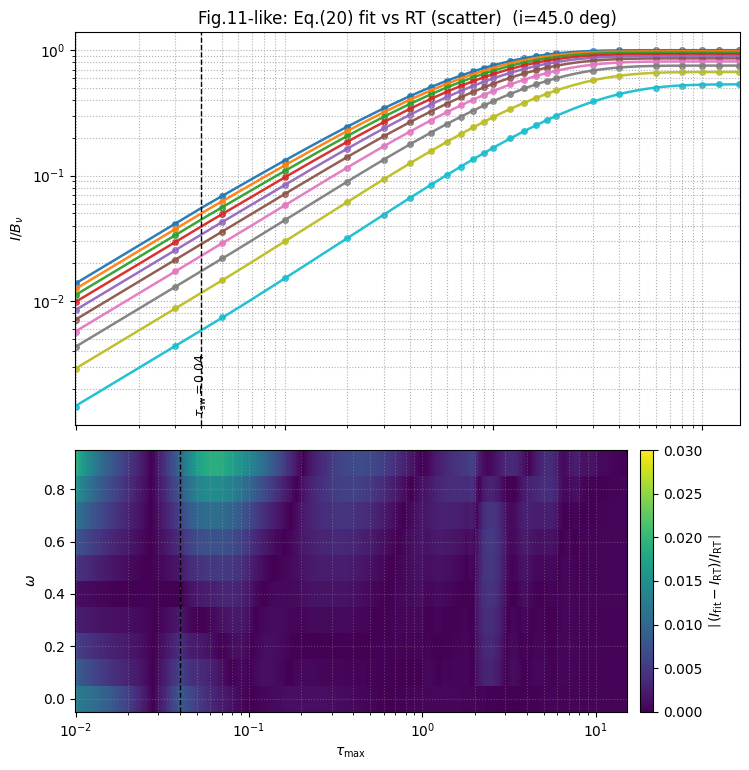

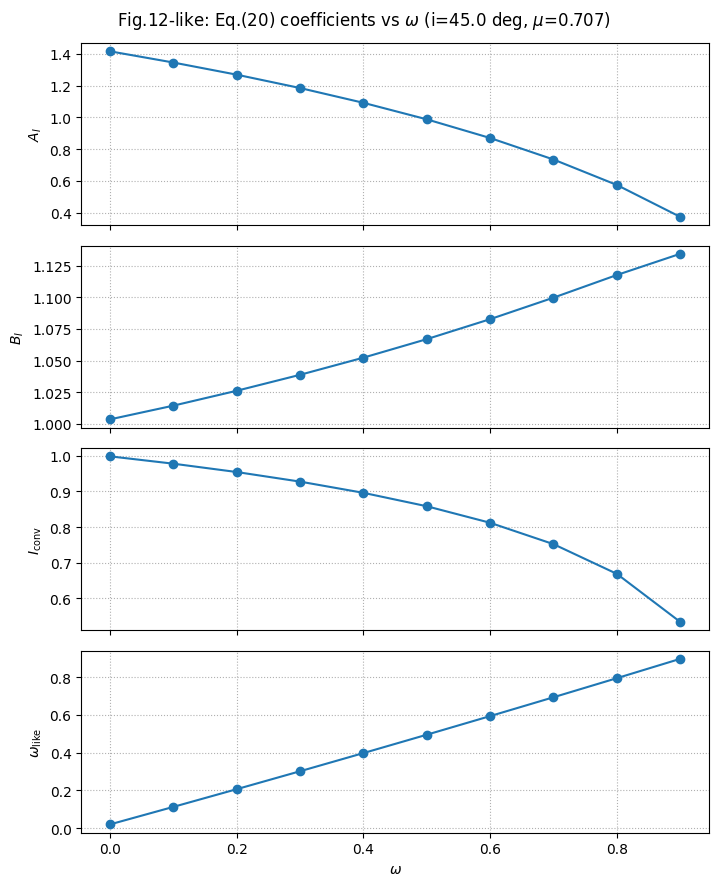

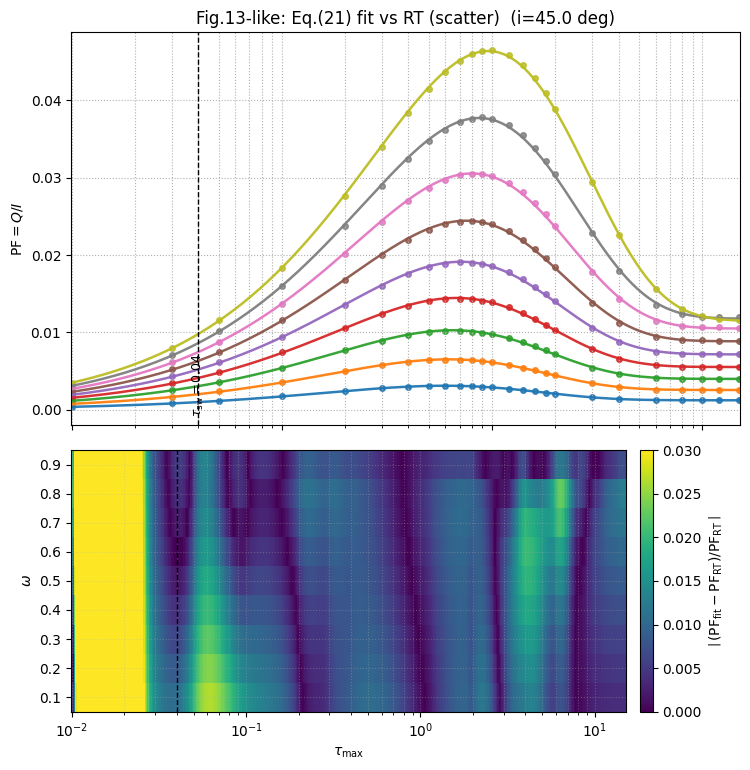

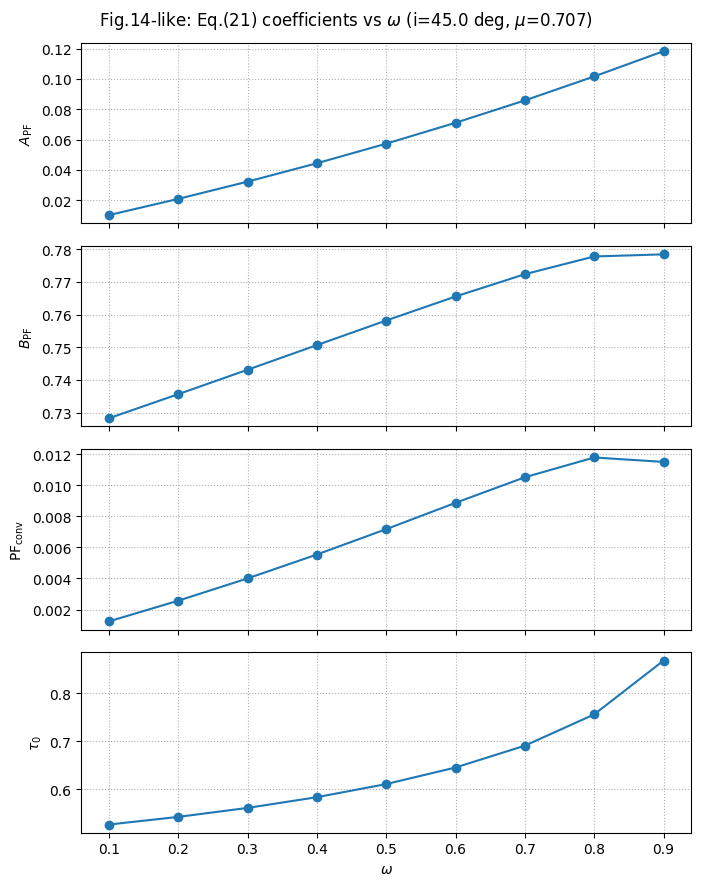

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

from emergentintensity import (
    interpolate_stokes,
    get_tau_grid_rt_only,
    compute_IQ_rt_on_grid,
    compute_PF_from_IQ,
    fit_eq20_eq21_coeffs_for_omegas,
    eq20_I_over_Bnu,
    eq21_PF,
    TAU_SWITCH_EQ20,
)

# ============================================================
# User settings
# ============================================================
inc_deg = 45.0
omega_grid_I  = np.round(np.linspace(0.0, 0.9, 10), 1)  # include omega=0 for I
omega_grid_PF = np.round(np.linspace(0.0, 0.9, 10), 1)  # omega=0 excluded internally for PF

tau_dense_n = 400

# linear colormap range for |relative error|
err_vmin = 0.0
err_vmax = 0.03  

# ============================================================
# Helpers
# ============================================================
def relerr_abs(model, truth, floor=1e-12):
    model = np.asarray(model, dtype=float)
    truth = np.asarray(truth, dtype=float)
    denom = np.maximum(np.abs(truth), float(floor))
    return np.abs(model - truth) / denom

def _edges_from_centers_log(x):
    x = np.asarray(x, dtype=float)
    lx = np.log10(x)
    d = np.diff(lx)
    e = np.empty(len(x) + 1, dtype=float)
    e[1:-1] = 0.5 * (lx[:-1] + lx[1:])
    e[0] = lx[0] - 0.5 * d[0]
    e[-1] = lx[-1] + 0.5 * d[-1]
    return 10 ** e

def _edges_from_centers_lin(x):
    x = np.asarray(x, dtype=float)
    if len(x) == 1:
        return np.array([x[0] - 0.5, x[0] + 0.5], dtype=float)
    d = np.diff(x)
    e = np.empty(len(x) + 1, dtype=float)
    e[1:-1] = 0.5 * (x[:-1] + x[1:])
    e[0] = x[0] - 0.5 * d[0]
    e[-1] = x[-1] + 0.5 * d[-1]
    return e

# ============================================================
# Prepare RT tau and fit coefficients
# ============================================================
tau_rt = np.asarray(get_tau_grid_rt_only(), dtype=float)
tau_min_rt = float(tau_rt[0])
tau_max_rt = float(tau_rt[-1])
tau_dense = np.logspace(np.log10(tau_min_rt), np.log10(tau_max_rt), tau_dense_n)

coeff_I, coeff_PF, tau_fit, mu = fit_eq20_eq21_coeffs_for_omegas(
    inc_deg=inc_deg,
    omega_list_I=omega_grid_I,
    omega_list_PF=omega_grid_PF,
    tau_grid=tau_rt,
    tau_switch=TAU_SWITCH_EQ20,
    exclude_omega0_in_PF=True,
)

print(f"inclination i = {inc_deg} deg, mu = {mu:.6f}")
print(f"RT tau range  : [{tau_min_rt:g}, {tau_max_rt:g}] (N={len(tau_rt)})")
print(f"Eq(20) switch : tau_sw = {TAU_SWITCH_EQ20:g}")

# ============================================================
# FIG 11-like: I/Bnu (top) + |relative error| colormap (bottom)
#   - RT scatter at tau_rt
#   - Fit curve at tau_dense
#   - Error computed at tau_dense using RT interpolation as truth (not drawn)
# ============================================================
W_I = np.array([float(o) for o in omega_grid_I], dtype=float)
ERR_I = np.empty((len(W_I), len(tau_dense)), dtype=float)

fig11, (ax11_top, ax11_bot) = plt.subplots(
    2, 1, figsize=(7.6, 7.8),
    gridspec_kw={"height_ratios": [3, 2]},
    sharex=True
)

for omega in W_I:
    # RT scatter points (tau_rt grid)
    I_rt, Q_rt = compute_IQ_rt_on_grid(tau_rt, omega, inc_deg)
    ax11_top.scatter(tau_rt, I_rt, s=16, marker="o", alpha=0.85)

    # Fit smooth curve
    p = coeff_I[float(omega)]
    I_fit = eq20_I_over_Bnu(
        tau_dense, mu,
        p["omega_like"], p["I_conv"], p["A_I"], p["B_I"],
        tau_switch=TAU_SWITCH_EQ20
    )
    ax11_top.plot(tau_dense, I_fit, lw=1.8, alpha=0.95)

    # Truth for error: RT interpolation at dense tau
    I_truth = np.array([interpolate_stokes(float(t), float(omega), float(inc_deg))[0] for t in tau_dense], dtype=float)
    ERR_I[np.where(W_I == omega)[0][0], :] = relerr_abs(I_fit, I_truth, floor=1e-12)

ax11_top.set_xscale("log")
ax11_top.set_yscale("log")
ax11_top.grid(True, which="both", ls=":")
ax11_top.set_ylabel(r"$I/B_\nu$")
ax11_top.set_title(fr"Fig.11-like: Eq.(20) fit vs RT (scatter)  (i={inc_deg} deg)")

ax11_top.axvline(TAU_SWITCH_EQ20, color="k", ls="--", lw=1.0)
ax11_top.text(
    TAU_SWITCH_EQ20, 0.02, r"$\tau_{\rm sw}=0.04$",
    transform=ax11_top.get_xaxis_transform(),
    ha="center", va="bottom", fontsize=9, rotation=90
)

# Bottom: linear colormap of |relative error|
tau_edges = _edges_from_centers_log(tau_dense)
omega_edges = _edges_from_centers_lin(W_I)

pcm11 = ax11_bot.pcolormesh(
    tau_edges, omega_edges, ERR_I,
    norm=Normalize(vmin=err_vmin, vmax=err_vmax),
    shading="auto"
)
ax11_bot.set_xscale("log")
ax11_bot.set_ylabel(r"$\omega$")
ax11_bot.set_xlabel(r"$\tau_{\max}$")
ax11_bot.grid(True, which="both", ls=":", alpha=0.35)
ax11_bot.axvline(TAU_SWITCH_EQ20, color="k", ls="--", lw=1.0)

cbar11 = fig11.colorbar(pcm11, ax=ax11_bot, pad=0.02)
cbar11.set_label(r"$\left|\,(I_{\rm fit}-I_{\rm RT})/I_{\rm RT}\,\right|$")

plt.tight_layout()
plt.show()




# ============================================================
# FIG 12-like: coefficients for Eq.(20) as function of omega (i fixed)
#   - include omega=0 for I
#   - plot what you actually fitted/stored in coeff_I
# ============================================================
# Extract coefficient arrays (handle missing keys robustly)
omega_list_coeff_I = sorted([float(o) for o in coeff_I.keys()])
omega_arr_coeff_I = np.array(omega_list_coeff_I, dtype=float)

A_I = np.array([float(coeff_I[o]["A_I"]) for o in omega_list_coeff_I], dtype=float)
B_I = np.array([float(coeff_I[o]["B_I"]) for o in omega_list_coeff_I], dtype=float)
I_conv = np.array([float(coeff_I[o]["I_conv"]) for o in omega_list_coeff_I], dtype=float)
omega_like = np.array([float(coeff_I[o]["omega_like"]) for o in omega_list_coeff_I], dtype=float)

fig12, axes12 = plt.subplots(4, 1, figsize=(7.2, 9.0), sharex=True)
(axA, axB, axIc, axOl) = axes12

axA.plot(omega_arr_coeff_I, A_I, "o-")
axA.set_ylabel(r"$A_I$")
axA.grid(True, ls=":")

axB.plot(omega_arr_coeff_I, B_I, "o-")
axB.set_ylabel(r"$B_I$")
axB.grid(True, ls=":")

axIc.plot(omega_arr_coeff_I, I_conv, "o-")
axIc.set_ylabel(r"$I_{\rm conv}$")
axIc.grid(True, ls=":")

axOl.plot(omega_arr_coeff_I, omega_like, "o-")
axOl.set_ylabel(r"$\omega_{\rm like}$")
axOl.set_xlabel(r"$\omega$")
axOl.grid(True, ls=":")

fig12.suptitle(fr"Fig.12-like: Eq.(20) coefficients vs $\omega$ (i={inc_deg} deg, $\mu$={mu:.3f})")
plt.tight_layout()
plt.show()

# ============================================================
# FIG 13-like: PF (=Q/I) (top) + |relative error| colormap (bottom)
#   - omega=0 excluded
# ============================================================
W_PF = np.array(sorted([float(o) for o in omega_grid_PF if abs(float(o)) > 1e-15]), dtype=float)
ERR_PF = np.empty((len(W_PF), len(tau_dense)), dtype=float)

fig13, (ax13_top, ax13_bot) = plt.subplots(
    2, 1, figsize=(7.6, 7.8),
    gridspec_kw={"height_ratios": [3, 2]},
    sharex=True
)

for omega in W_PF:
    # RT scatter points on tau_rt grid
    I_rt, Q_rt = compute_IQ_rt_on_grid(tau_rt, omega, inc_deg)
    PF_rt = compute_PF_from_IQ(I_rt, Q_rt, floor_I=0.0)
    ax13_top.scatter(tau_rt, PF_rt, s=16, marker="o", alpha=0.85)

    # Fit smooth curve
    p = coeff_PF[float(omega)]
    PF_fit = eq21_PF(tau_dense, p["A_PF"], p["B_PF"], p["PF_conv"], p["tau0"])
    ax13_top.plot(tau_dense, PF_fit, lw=1.8, alpha=0.95)

    # Truth at dense tau (RT interpolation)
    I_truth = np.array([interpolate_stokes(float(t), float(omega), float(inc_deg))[0] for t in tau_dense], dtype=float)
    Q_truth = np.array([interpolate_stokes(float(t), float(omega), float(inc_deg))[1] for t in tau_dense], dtype=float)
    PF_truth = compute_PF_from_IQ(I_truth, Q_truth, floor_I=0.0)

    ERR_PF[np.where(W_PF == omega)[0][0], :] = relerr_abs(PF_fit, PF_truth, floor=1e-4)

ax13_top.set_xscale("log")
ax13_top.grid(True, which="both", ls=":")
ax13_top.set_ylabel(r"${\rm PF}=Q/I$")
ax13_top.set_title(fr"Fig.13-like: Eq.(21) fit vs RT (scatter)  (i={inc_deg} deg)")

ax13_top.axvline(TAU_SWITCH_EQ20, color="k", ls="--", lw=1.0)
ax13_top.text(
    TAU_SWITCH_EQ20, 0.02, r"$\tau_{\rm sw}=0.04$",
    transform=ax13_top.get_xaxis_transform(),
    ha="center", va="bottom", fontsize=9, rotation=90
)

# Bottom: linear colormap of |relative error|
tau_edges_pf = _edges_from_centers_log(tau_dense)
omega_edges_pf = _edges_from_centers_lin(W_PF)

pcm13 = ax13_bot.pcolormesh(
    tau_edges_pf, omega_edges_pf, ERR_PF,
    norm=Normalize(vmin=err_vmin, vmax=err_vmax),
    shading="auto"
)
ax13_bot.set_xscale("log")
ax13_bot.set_ylabel(r"$\omega$")
ax13_bot.set_xlabel(r"$\tau_{\max}$")
ax13_bot.grid(True, which="both", ls=":", alpha=0.35)
ax13_bot.axvline(TAU_SWITCH_EQ20, color="k", ls="--", lw=1.0)

cbar13 = fig13.colorbar(pcm13, ax=ax13_bot, pad=0.02)
cbar13.set_label(r"$\left|\,({\rm PF}_{\rm fit}-{\rm PF}_{\rm RT})/{\rm PF}_{\rm RT}\,\right|$")

plt.tight_layout()
plt.show()

# ============================================================
# FIG 14-like: coefficients for Eq.(21) PF fit as function of omega (i fixed)
#   - exclude omega=0 (PF is identically 0)
# ============================================================
omega_list_coeff_PF = sorted([float(o) for o in coeff_PF.keys() if abs(float(o)) > 1e-15])
omega_arr_coeff_PF = np.array(omega_list_coeff_PF, dtype=float)

A_PF = np.array([float(coeff_PF[o]["A_PF"]) for o in omega_list_coeff_PF], dtype=float)
B_PF = np.array([float(coeff_PF[o]["B_PF"]) for o in omega_list_coeff_PF], dtype=float)
PF_conv = np.array([float(coeff_PF[o]["PF_conv"]) for o in omega_list_coeff_PF], dtype=float)
tau0 = np.array([float(coeff_PF[o]["tau0"]) for o in omega_list_coeff_PF], dtype=float)

fig14, axes14 = plt.subplots(4, 1, figsize=(7.2, 9.0), sharex=True)
(axAp, axBp, axPc, axT0) = axes14

axAp.plot(omega_arr_coeff_PF, A_PF, "o-")
axAp.set_ylabel(r"$A_{\rm PF}$")
axAp.grid(True, ls=":")

axBp.plot(omega_arr_coeff_PF, B_PF, "o-")
axBp.set_ylabel(r"$B_{\rm PF}$")
axBp.grid(True, ls=":")

axPc.plot(omega_arr_coeff_PF, PF_conv, "o-")
axPc.set_ylabel(r"${\rm PF}_{\rm conv}$")
axPc.grid(True, ls=":")

axT0.plot(omega_arr_coeff_PF, tau0, "o-")
axT0.set_ylabel(r"$\tau_0$")
axT0.set_xlabel(r"$\omega$")
axT0.grid(True, ls=":")

fig14.suptitle(fr"Fig.14-like: Eq.(21) coefficients vs $\omega$ (i={inc_deg} deg, $\mu$={mu:.3f})")
plt.tight_layout()
plt.show()